# Customer Investment Needs — EDA & Preprocessing

**Goal:** Understand customer data, engineer features, and assess whether unsupervised clustering can support a downstream recommendation system.
**Scope:** Preprocessing and exploration only — modelling is in a separate notebook.

> **Note:** Plots are defined in `plots.py` in the same directory.

---

## Notebook Structure

1. Imports & Setup
2. Data Loading & Exploration
3. Data Cleaning
4. Skew Reduction
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Supervised EDA
8. FAMD (Dimensionality Reduction)
9. GMM Clustering
10. Summary, Findings & Next Steps

---
## 1. Imports & Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.stats import pointbiserialr
import prince
import importlib
import plots
importlib.reload(plots)
from utilities import (
    run_experiment,
    #plot_f1_barchart
)

# Set global plot style (dark theme, fonts, colors) — aesthetic only
sns.set_theme(style='darkgrid', context='notebook', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#444',
    'grid.color': '#333',
})

SEED = 50
np.random.seed(SEED)
print('Setup complete ✓')

Setup complete ✓


---
## 2. Data Loading & Exploration

**Source:** `Dataset2_Needs.xls` — three sheets:
- `Needs`: one row per customer, features + two binary targets
- `Products`: product catalogue with risk profiles
- `Metadata`: column descriptions

**Targets:**
- `IncomeInvestment` — propensity for lump-sum / income-generating products
- `AccumulationInvestment` — propensity for regular contribution products

In [16]:
file_path = 'Dataset2_Needs.xls'

needs_df    = pd.read_excel(file_path, sheet_name='Needs')
products_df = pd.read_excel(file_path, sheet_name='Products')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

print('needs_df    :', needs_df.shape)
print('products_df :', products_df.shape)
print('metadata_df :', metadata_df.shape)
print(metadata_df.head())
needs_df.head()

needs_df    : (5000, 10)
products_df : (11, 3)
metadata_df : (29, 2)
        Metadata                     Unnamed: 1
0        Clients                            NaN
1             ID                   Numerical ID
2            Age                  Age, in years
3         Gender  Gender (Female = 1, Male = 0)
4  FamilyMembers           Number of components


In [11]:
print('Dtypes:\n', needs_df.dtypes)
print('\nMissing values:\n', needs_df.isnull().sum())
needs_df.describe()

Dtypes:
 ID                          int64
Age                         int64
Gender                      int64
FamilyMembers               int64
FinancialEducation        float64
RiskPropensity            float64
Income                    float64
Wealth                    float64
IncomeInvestment            int64
AccumulationInvestment      int64
dtype: object

Missing values:
 ID                        0
Age                       0
Gender                    0
FamilyMembers             0
FinancialEducation        0
RiskPropensity            0
Income                    0
Wealth                    0
IncomeInvestment          0
AccumulationInvestment    0
dtype: int64


,ID,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,55.253400,0.492000,2.510600,0.419123,0.362686,62.994324,93.806264,0.383600,0.513200
std,1443.520003,11.971694,0.499986,0.761842,0.151383,0.151124,44.359771,105.471004,0.486311,0.499876
min,1.000000,18.000000,0.000000,1.000000,0.036099,0.024790,1.537765,1.057415,0.000000,0.000000
25%,1250.750000,47.000000,0.000000,2.000000,0.308067,0.246444,30.596490,38.311097,0.000000,0.000000
50%,2500.500000,55.000000,0.000000,3.000000,0.416735,0.354526,53.399368,66.070582,0.000000,1.000000
75%,3750.250000,63.000000,1.000000,3.000000,0.523393,0.467125,84.122304,114.824753,1.000000,1.000000
max,5000.000000,97.000000,1.000000,5.000000,0.902933,0.882709,365.323385,2233.228433,1.000000,1.000000


---
## 3. Data Cleaning

- Drop `ID` (not informative for modelling)
- Shuffle rows reproducibly
- Separate features from targets
- Check class balance

In [12]:
needs_df.drop(columns='ID', inplace=True)

df = needs_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

x_df     = df[['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                'RiskPropensity', 'Income', 'Wealth']]
y_inc_df = df['IncomeInvestment']
y_acc_df = df['AccumulationInvestment']

print(f'Features: {x_df.shape}  |  Targets: {y_inc_df.shape}')

Features: (5000, 7)  |  Targets: (5000,)


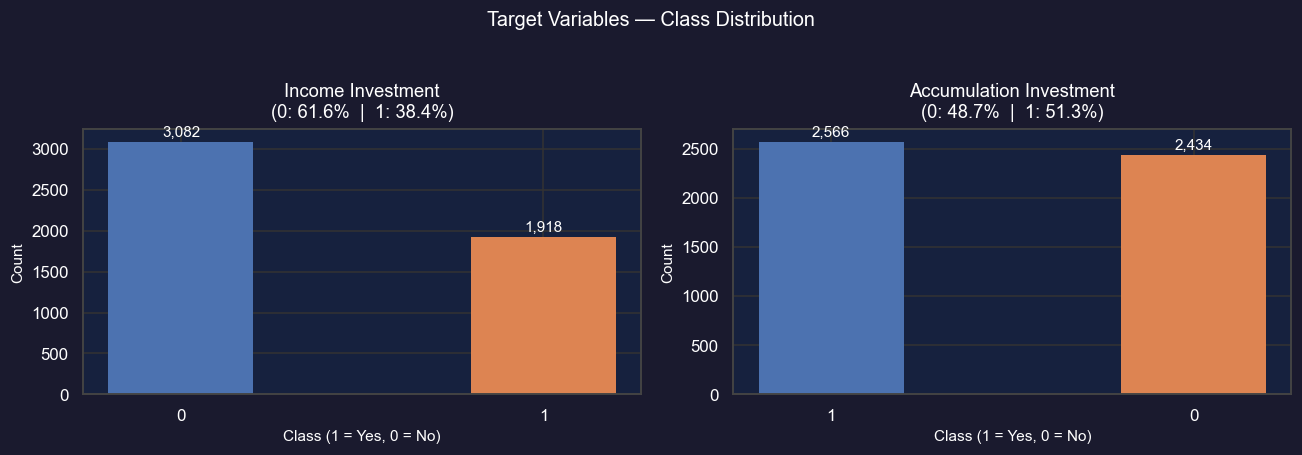

In [13]:
plots.plot_target_distribution(df)

---
## 4. Skew Reduction

`Wealth` and `Income` are heavily right-skewed. We apply `log1p` — safe for zero values.

In [14]:
transformed_df = df.copy()

transformed_df['Wealth_log'] = np.log1p(transformed_df['Wealth'])
transformed_df['Income_log'] = np.log1p(transformed_df['Income'])

skew_table = pd.DataFrame({
    'Original Skew': [df['Wealth'].skew(), df['Income'].skew()],
    'After log1p':   [transformed_df['Wealth_log'].skew(), transformed_df['Income_log'].skew()],
}, index=['Wealth', 'Income'])

print(skew_table.round(3))

        Original Skew  After log1p
Wealth          5.831       -0.371
Income          1.377       -0.618


KeyError: 'Wealth_power'

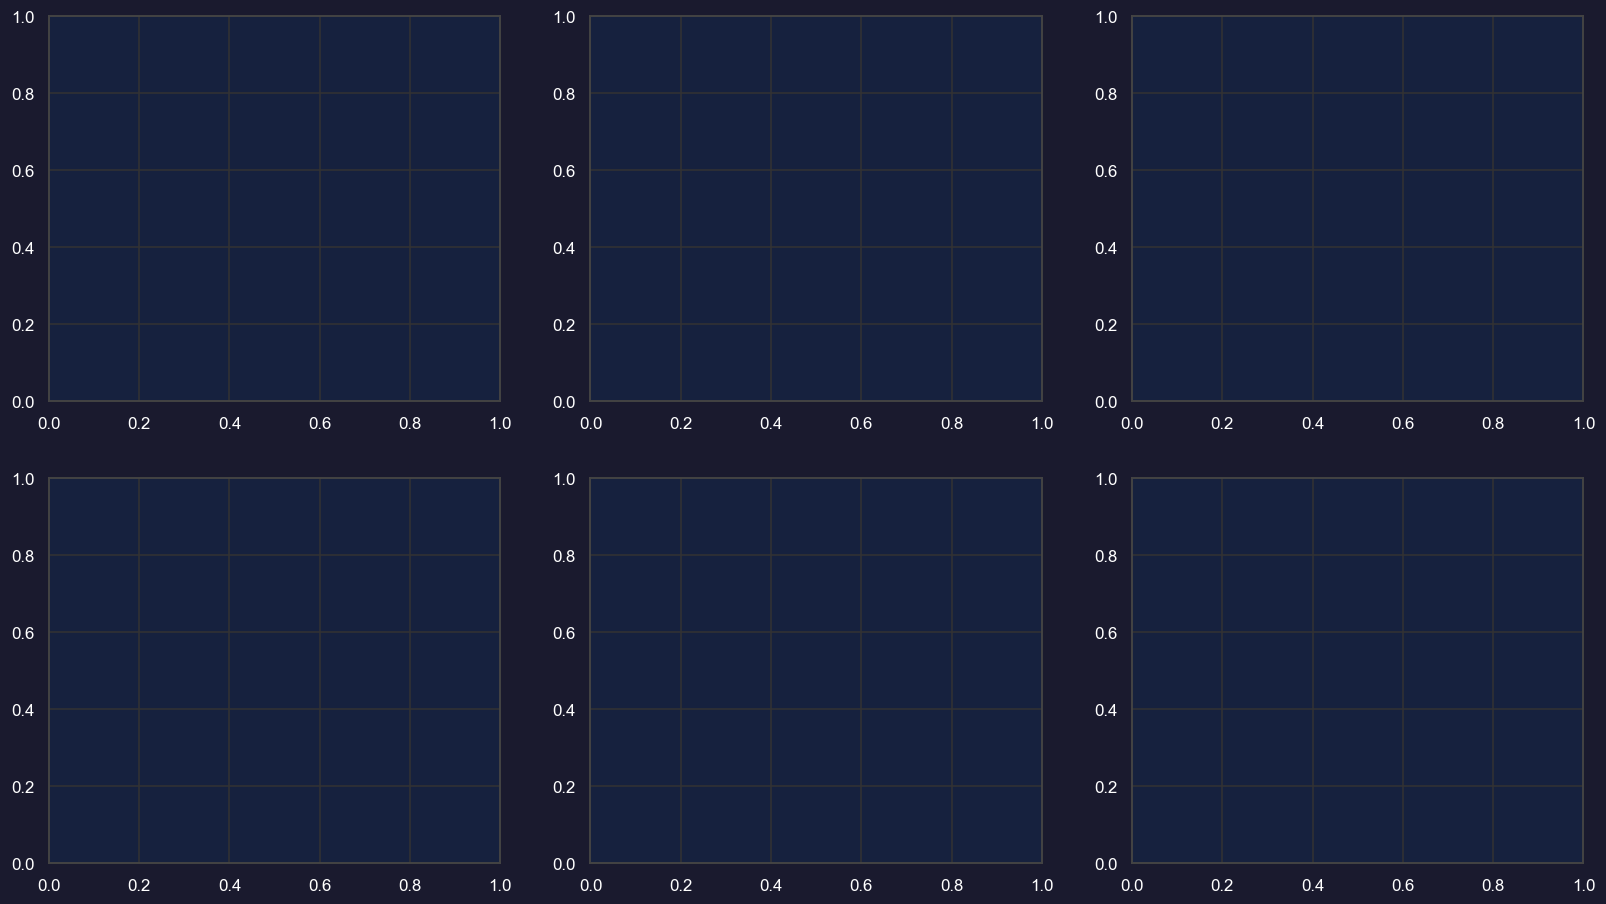

In [15]:
plots.plot_skew_comparison(transformed_df)

---
## 5. Feature Engineering

| Feature | Formula | Rationale |
|---|---|---|
| `IncomePerFamilyMember_log` | log1p(Income / FamilyMembers) | Disposable income proxy |
| `Income_Wealth_Ratio_log` | log1p(Income / Wealth) | Lifecycle stage: accumulator vs. depleter |
| `SophisticationScore` | FinancialEducation × RiskPropensity | ⚠️ Highly collinear with inputs (~0.87–0.91) — evaluated in supervised EDA |

In [8]:
feature_df = transformed_df.copy()

# Per-capita income
feature_df['IncomePerFamilyMember'] = (
    feature_df['Income'] / feature_df['FamilyMembers'].replace(0, np.nan)
).fillna(feature_df['Income'].median() / feature_df['FamilyMembers'].median())
feature_df['IncomePerFamilyMember_log'] = np.log1p(feature_df['IncomePerFamilyMember'])

# Financial lifecycle ratio
feature_df['Income_Wealth_Ratio'] = (
    feature_df['Income'] / feature_df['Wealth'].replace(0, np.nan)
).fillna(0)
feature_df['Income_Wealth_Ratio_log'] = np.log1p(feature_df['Income_Wealth_Ratio'])

# Behavioural interaction
feature_df['SophisticationScore'] = feature_df['FinancialEducation'] * feature_df['RiskPropensity']

# Gender as categorical (required by FAMD)
feature_df['Gender'] = feature_df['Gender'].astype('category')

NUMERICAL_FEATURES = [
    'Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity',
    'Wealth_log', 'Income_log',
    'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log',
    'SophisticationScore',
]
CATEGORICAL_FEATURES = ['Gender']
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

feature_df = feature_df[ALL_FEATURES]
print(f'Feature matrix: {feature_df.shape}')
print(feature_df.dtypes)

Feature matrix: (5000, 10)
Age                             int64
FamilyMembers                   int64
FinancialEducation            float64
RiskPropensity                float64
Wealth_log                    float64
Income_log                    float64
IncomePerFamilyMember_log     float64
Income_Wealth_Ratio_log       float64
SophisticationScore           float64
Gender                       category
dtype: object


---
## 6. Exploratory Data Analysis (EDA)

Feature distributions and pairwise correlations after engineering.

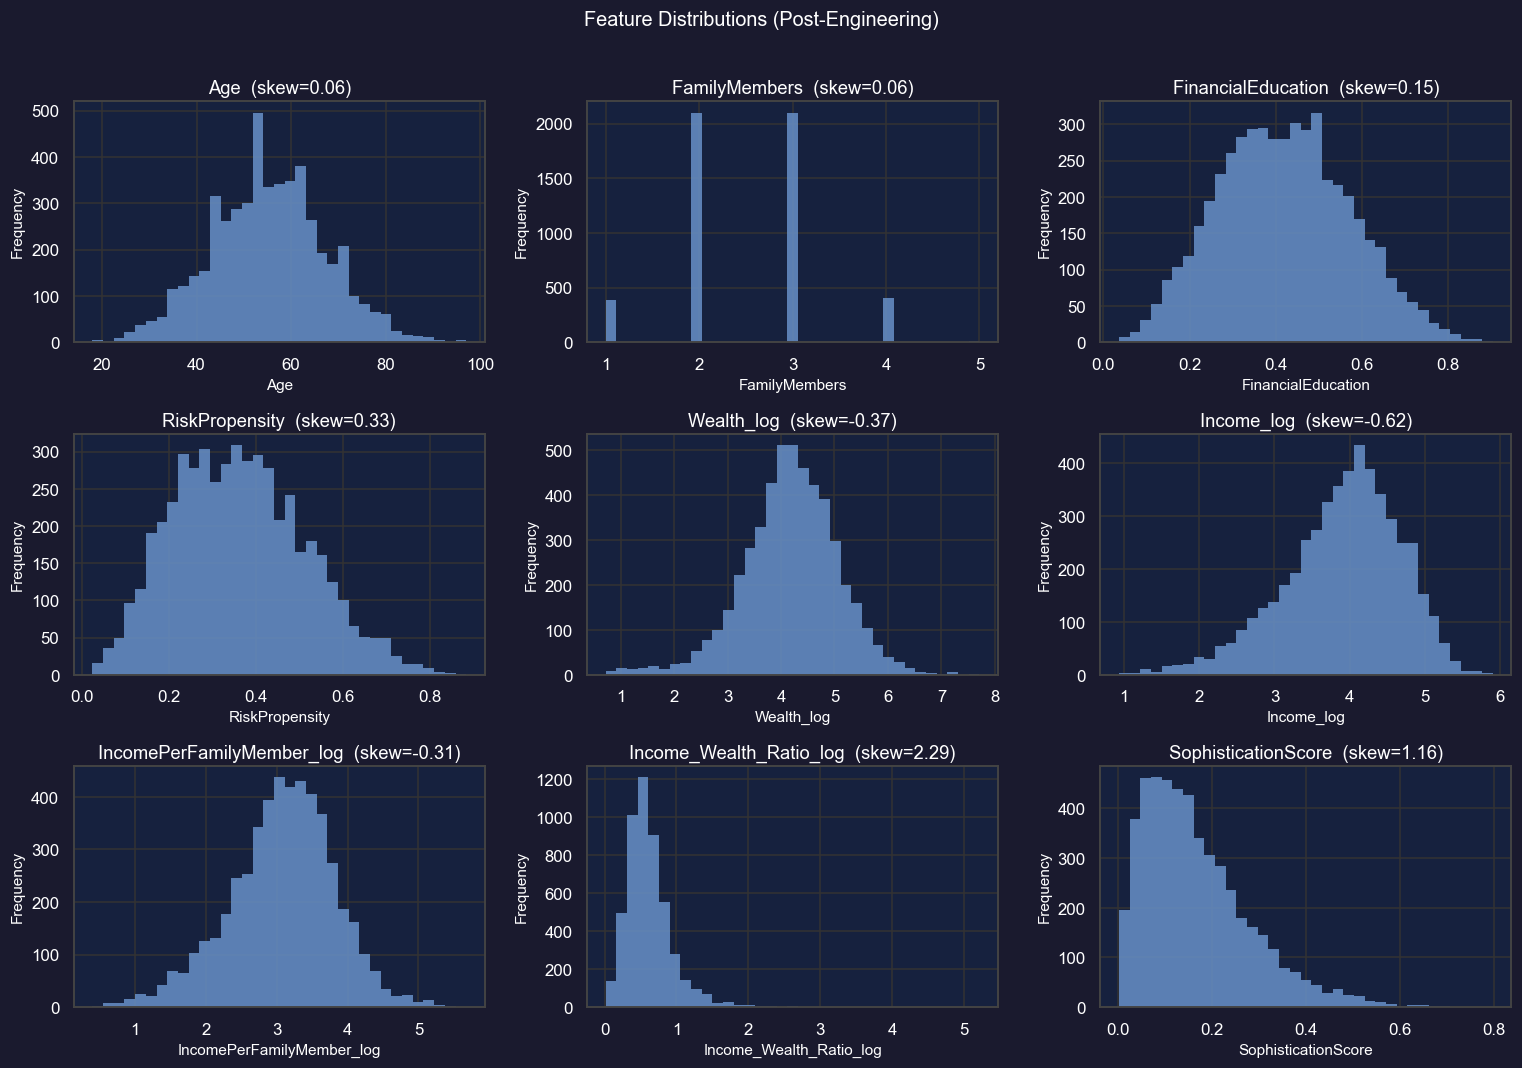

In [9]:
plots.plot_feature_distributions(feature_df, NUMERICAL_FEATURES)

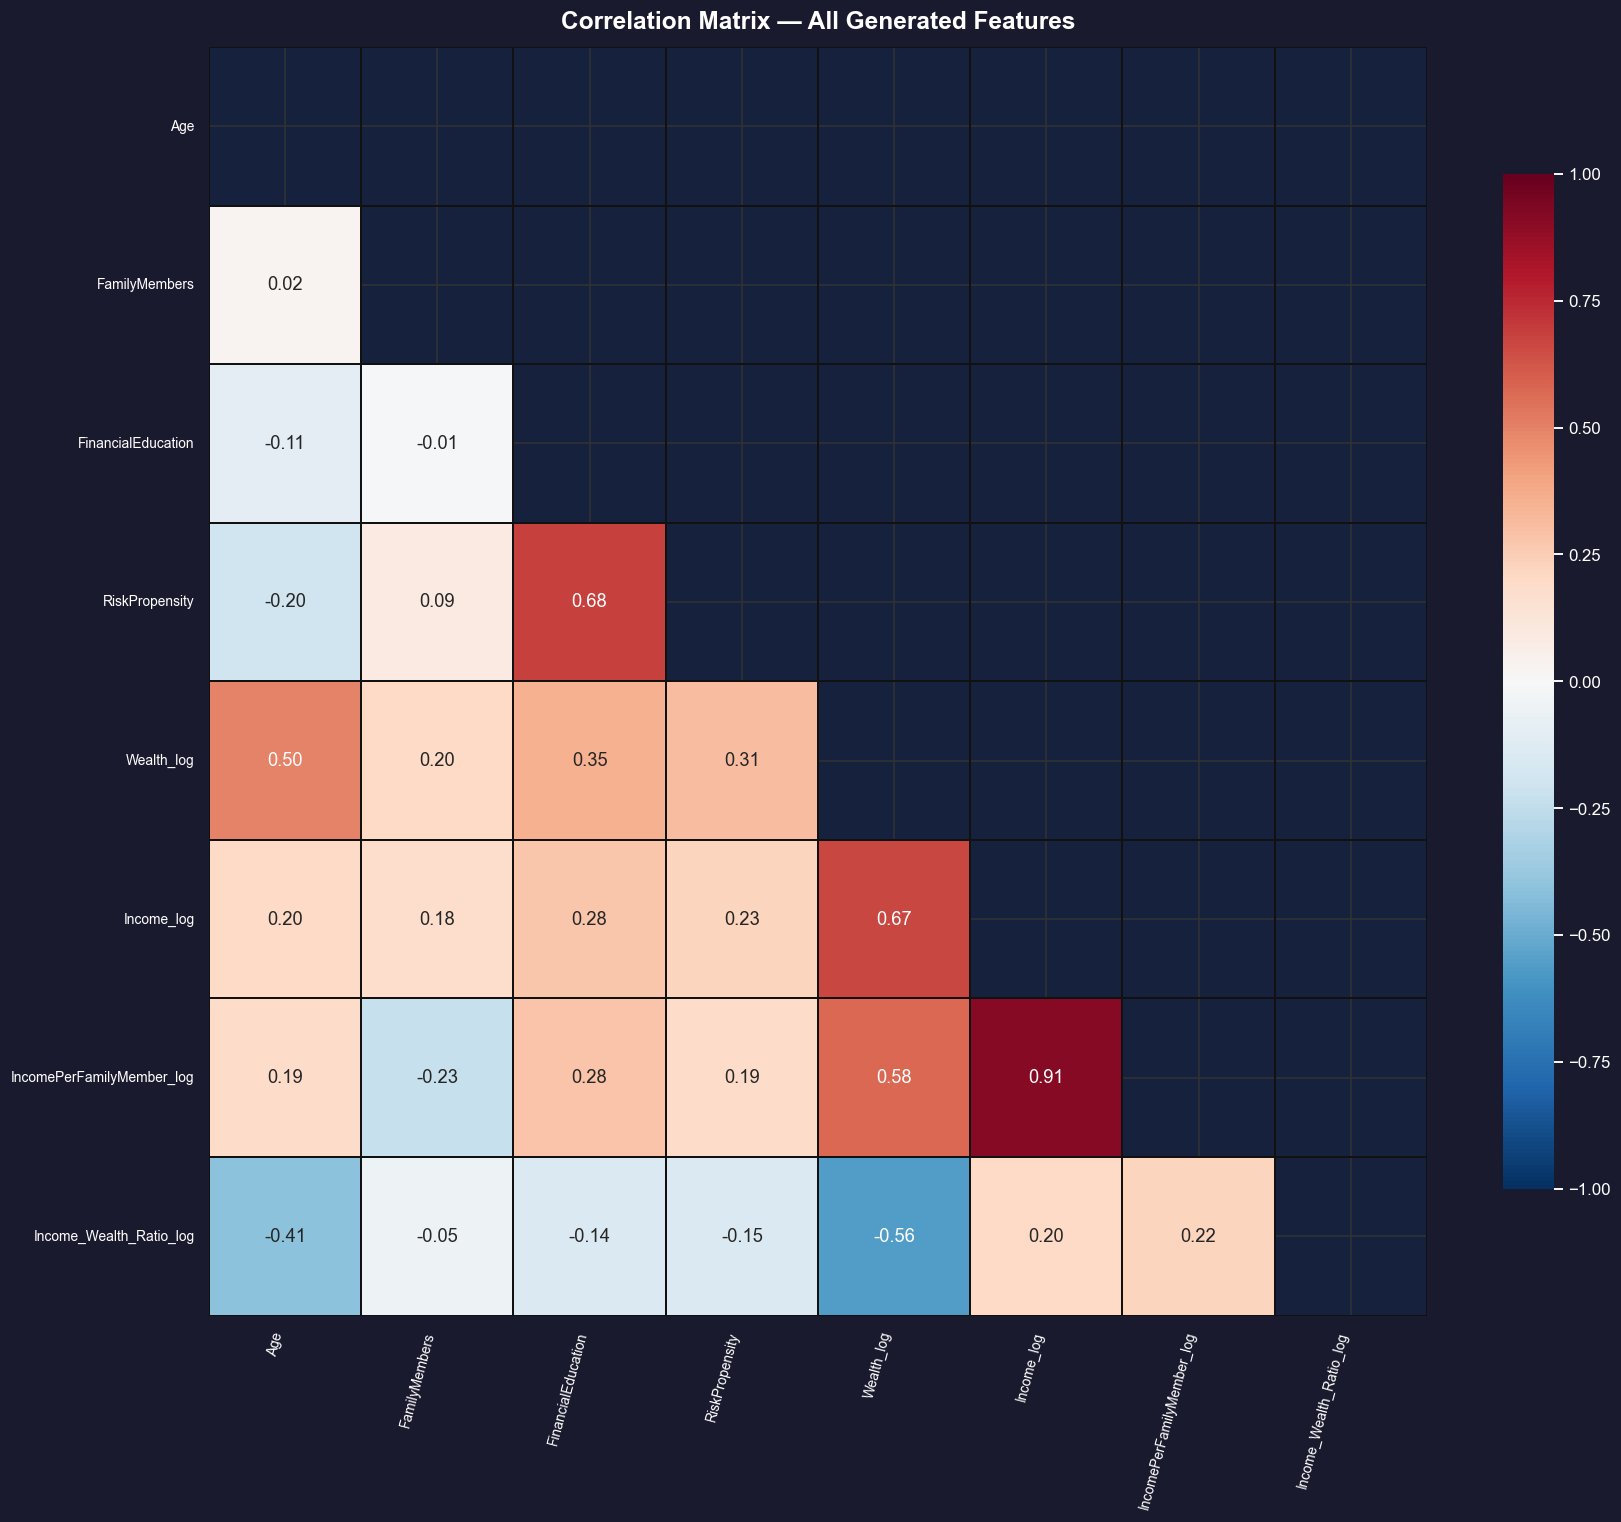


Coppie Altamente Correlate (|r| > 0.7): 1 rilevate
                Feature A  Feature B  Correlation
IncomePerFamilyMember_log Income_log     0.907685


In [42]:
plots.plot_correlation_matrix2(feature_df, NUMERICAL_FEATURES)

---
## 7. Supervised EDA

How features relate to the two targets — informs feature selection before modelling.

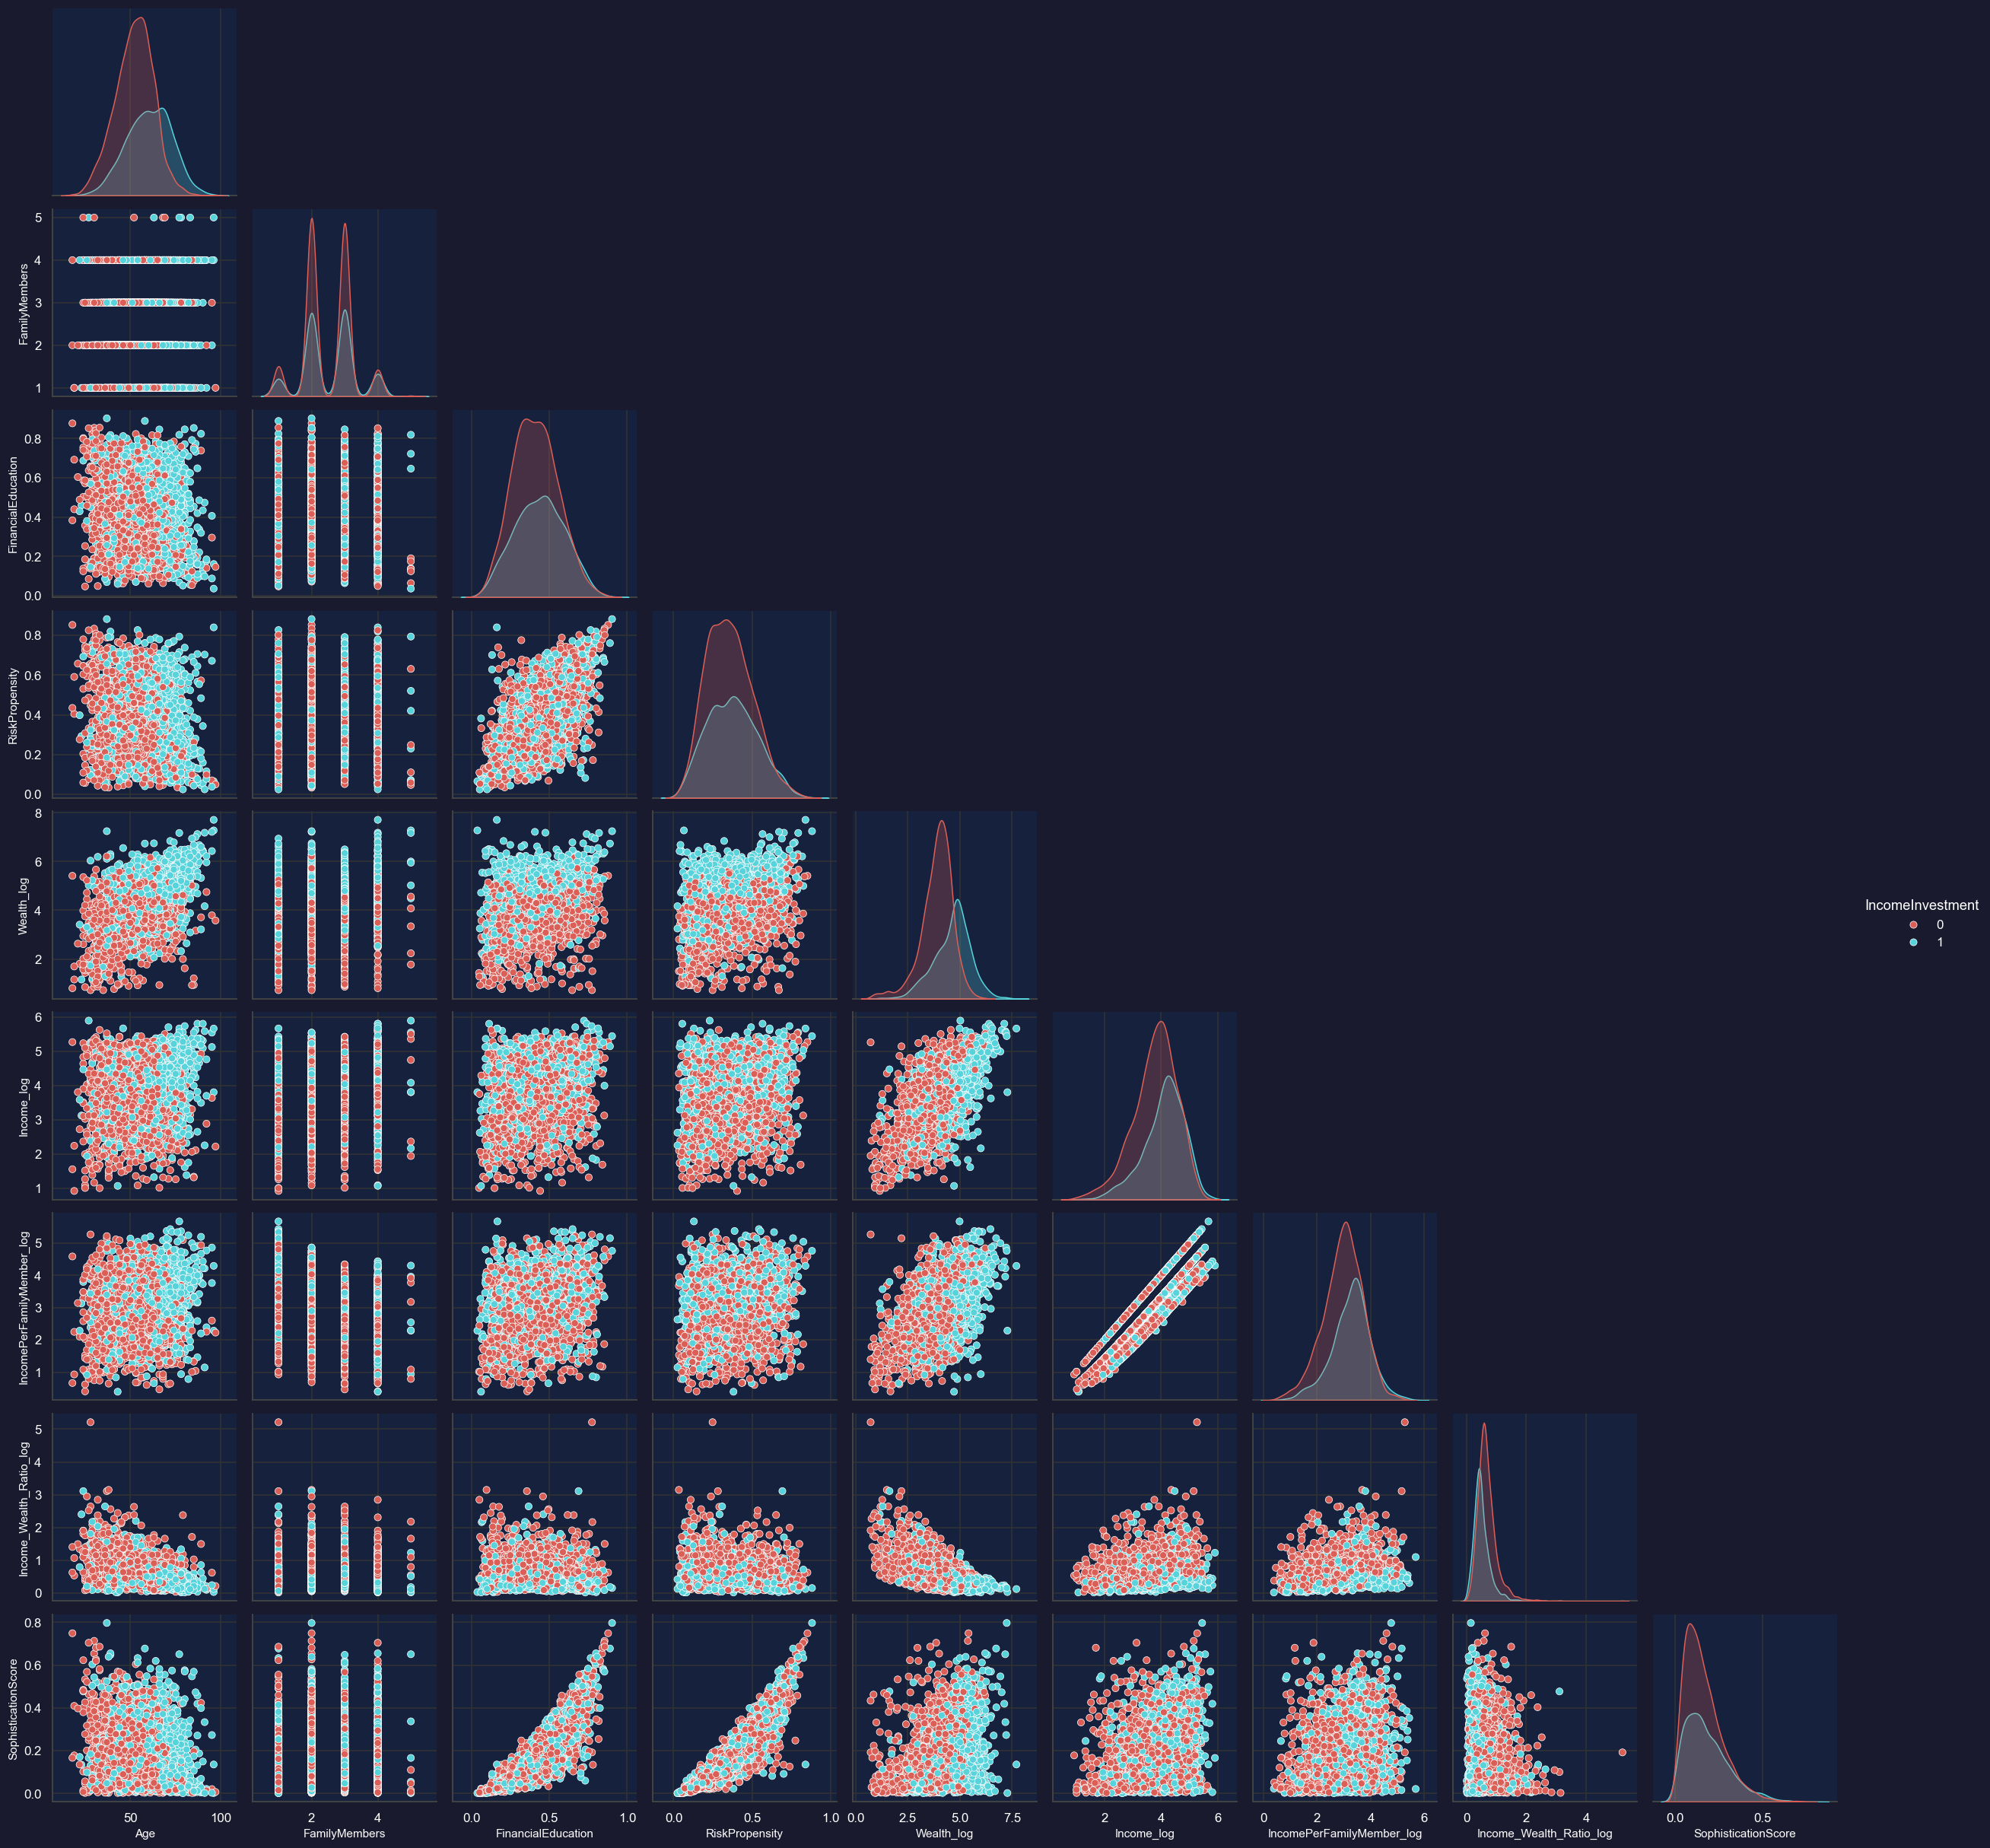

In [11]:
plot_df = feature_df.copy()
plot_df['IncomeInvestment'] = df['IncomeInvestment'].values
plot_df['AccumulationInvestment'] = df['AccumulationInvestment'].values

colour = sns.color_palette("hls", 2)
_ = sns.pairplot(plot_df,
                 hue='IncomeInvestment',
                 corner=True,
                 palette=colour,
                 vars=NUMERICAL_FEATURES)
plt.show()

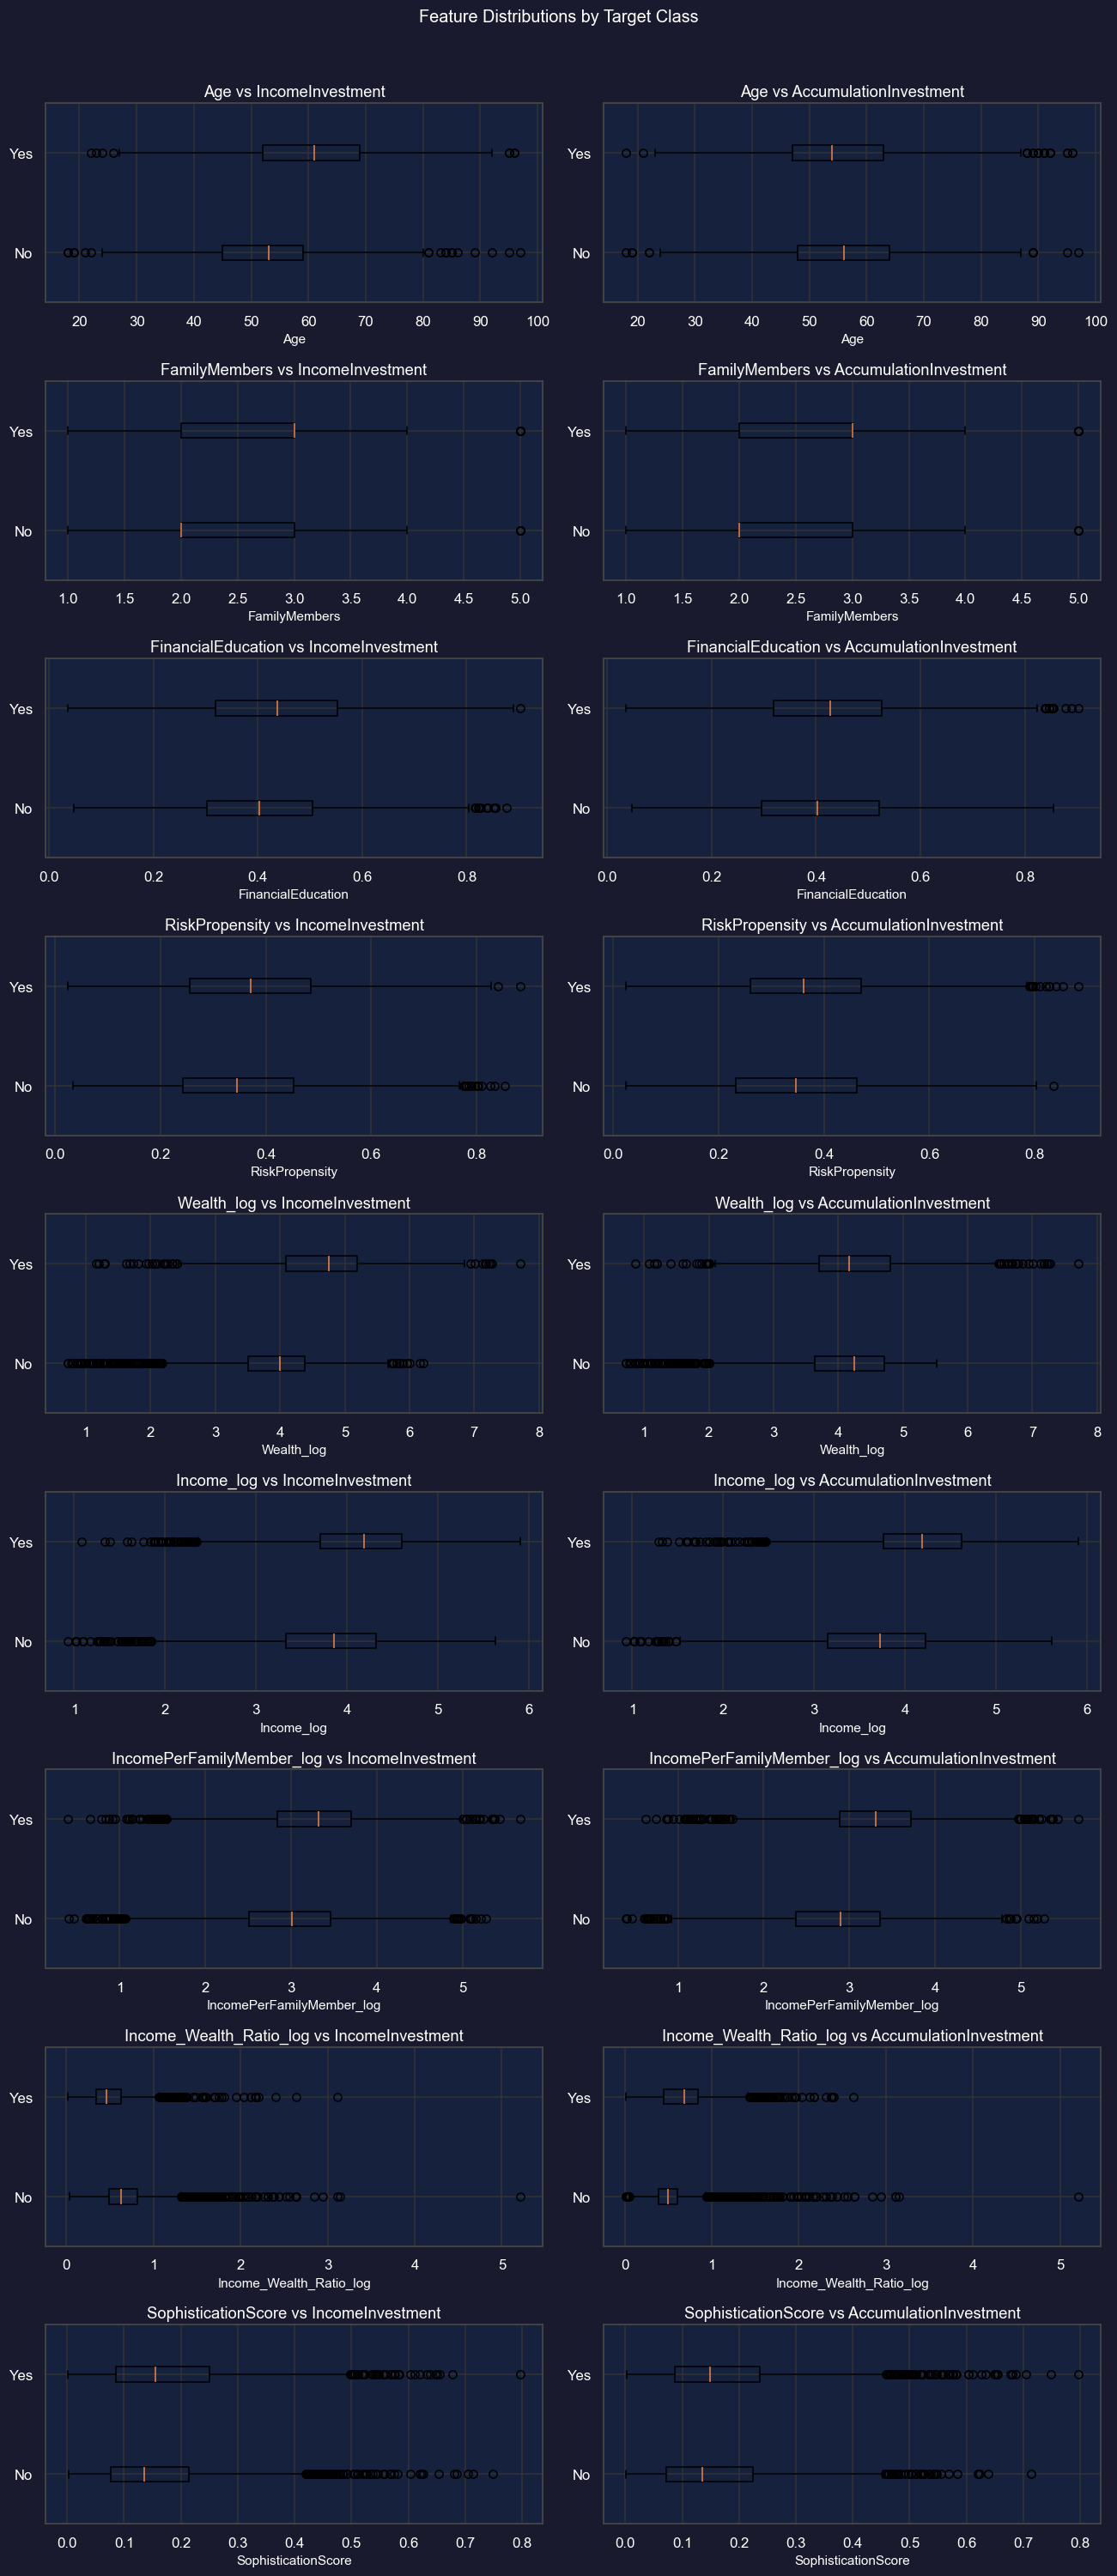

In [12]:
plots.plot_feature_vs_target(plot_df, NUMERICAL_FEATURES)

In [13]:
rows = []
for col in NUMERICAL_FEATURES:
    for target in ['IncomeInvestment', 'AccumulationInvestment']:
        r, p = pointbiserialr(plot_df[target], plot_df[col])
        rows.append({'Feature': col, 'Target': target,
                     'Correlation': round(r, 3), 'p-value': round(p, 4)})

corr_df = pd.DataFrame(rows).sort_values(['Target', 'Correlation'], ascending=[True, False])
print(corr_df.to_string(index=False))

                  Feature                 Target  Correlation  p-value
               Income_log AccumulationInvestment        0.322   0.0000
IncomePerFamilyMember_log AccumulationInvestment        0.292   0.0000
  Income_Wealth_Ratio_log AccumulationInvestment        0.195   0.0000
               Wealth_log AccumulationInvestment        0.119   0.0000
       FinancialEducation AccumulationInvestment        0.068   0.0000
           RiskPropensity AccumulationInvestment        0.068   0.0000
            FamilyMembers AccumulationInvestment        0.067   0.0000
      SophisticationScore AccumulationInvestment        0.067   0.0000
                      Age AccumulationInvestment       -0.014   0.3395
               Wealth_log       IncomeInvestment        0.404   0.0000
                      Age       IncomeInvestment        0.334   0.0000
               Income_log       IncomeInvestment        0.203   0.0000
IncomePerFamilyMember_log       IncomeInvestment        0.191   0.0000
      

### Supervised EDA — Findings

**AccumulationInvestment** — driven by income and cash flow.

| Top Features | Correlation |
|---|---|
| `Income_log` | +0.32 |
| `IncomePerFamilyMember_log` | +0.29 |
| `Income_Wealth_Ratio_log` | +0.20 |
| `Age` | -0.01 *(not significant)* |

**IncomeInvestment** — driven by wealth and age.

| Top Features | Correlation |
|---|---|
| `Wealth_log` | +0.40 |
| `Age` | +0.33 |
| `Income_Wealth_Ratio_log` | -0.25 |

`Income_Wealth_Ratio_log` has **opposite signs for the two targets** — the most informative engineered feature.

**Boxplot findings:** no single feature cleanly separates either target. Signal is spread across many weak features — ensemble methods (Random Forest, Gradient Boosting) are likely better suited than linear models.

**Feature decision:**
* ACCUMULATION: `SophisticationScore` dropped — correlations low with the target 0.067 add nothing beyond its parent features.

* INCOME:  `FamilyMembers` and `RiskPropensity` dropped - correlations low with the target - respectively 0.042 and 0.063. Futhermore `RiskPropensity` have a very high corelation (0.91) with `SophisticationScore` that is present in the Income feature

* Mantein the base feature - 'Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log' - for a comparison

In [14]:
print(feature_df.columns.tolist())
base_df = feature_df.drop(columns=['IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore'])
print(base_df.columns.tolist())

['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore', 'Gender']
['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'Gender']


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations

def create_interaction_features(df, base_columns):
    """
    Data una lista di feature base, genera tutte le interazioni di MOLTIPLICAZIONE a coppie
    e alcune DIVISIONI logiche, gestendo la divisione per zero.
    """
    df_inter = df.copy()
    
    # ==========================================
    # 1. MOLTIPLICAZIONI (Tutte le 21 coppie)
    # ==========================================
    # L'oggetto combinations genera tutte le coppie uniche senza doppioni
    for col1, col2 in combinations(base_columns, 2):
        new_col_name = f"{col1}_X_{col2}"
        df_inter[new_col_name] = df[col1] * df[col2]
        
    # ==========================================
    # 2. DIVISIONI (Scelte logiche e sicure)
    # ==========================================
    # Dividere tutto per tutto creerebbe 42 colonne (troppo rumore e variabili matematicamente instabili o infinte). 
    # Quindi creiamo una lista di "denominatori" che hanno senso logico:
    denominators = ['Age', 'FamilyMembers'] 
    
    # Una costante piccolissima per evitare l'errore "division by zero" o infiniti
    epsilon = 1e-5 
    
    for numer_col in base_columns:
        for denom_col in denominators:
            if numer_col != denom_col:
                new_col_name = f"{numer_col}_DIV_{denom_col}"
                # Mettiamo epsilon al denominatore nel caso ci siano zeri (es. Age=0 o Family=0)
                df_inter[new_col_name] = df[numer_col] / (df[denom_col] + epsilon)

    return df_inter


# ------------------------------------------------------------------------
# COME USARLO NEL TUO NOTEBOOK
# ------------------------------------------------------------------------
# 1. Definisci le tue 7 feature base (o i loro nomi se sono logaritmi)
le_mie_7_feature = ['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log']

# 2. Genera il super-dataframe
extended_feature_df = create_interaction_features(base_df, base_df.drop(columns='Gender'))

print(f"Numero colonne originali: {feature_df.shape[1]}")
print(f"Numero colonne dopo Interazioni: {extended_feature_df.shape[1]}")
extended_feature_df.head()

Numero colonne originali: 10
Numero colonne dopo Interazioni: 32


,Age,FamilyMembers,FinancialEducation,RiskPropensity,Wealth_log,Income_log,Gender,Age_X_FamilyMembers,Age_X_FinancialEducation,Age_X_RiskPropensity,...,Age_DIV_FamilyMembers,FamilyMembers_DIV_Age,FinancialEducation_DIV_Age,FinancialEducation_DIV_FamilyMembers,RiskPropensity_DIV_Age,RiskPropensity_DIV_FamilyMembers,Wealth_log_DIV_Age,Wealth_log_DIV_FamilyMembers,Income_log_DIV_Age,Income_log_DIV_FamilyMembers
0,64,3,0.563402,0.582442,5.122047,5.048320,0,192,36.057701,37.276314,...,21.333262,0.046875,0.008803,0.187800,0.009101,0.194147,0.080032,1.707343,0.078880,1.682768
1,57,2,0.197647,0.396081,4.219891,4.228070,1,114,11.265853,22.576633,...,28.499858,0.035088,0.003467,0.098823,0.006949,0.198040,0.074033,2.109935,0.074177,2.114024
2,53,2,0.404948,0.407098,3.602428,3.398944,0,106,21.462246,21.576215,...,26.499868,0.037736,0.007641,0.202473,0.007681,0.203548,0.067970,1.801205,0.064131,1.699463
3,67,3,0.610428,0.332732,4.726979,4.620627,1,201,40.898686,22.293037,...,22.333259,0.044776,0.009111,0.203475,0.004966,0.110910,0.070552,1.575654,0.068965,1.540204
4,57,3,0.507142,0.501799,4.122068,4.141433,1,171,28.907111,28.602570,...,18.999937,0.052632,0.008897,0.169047,0.008803,0.167266,0.072317,1.374018,0.072657,1.380473


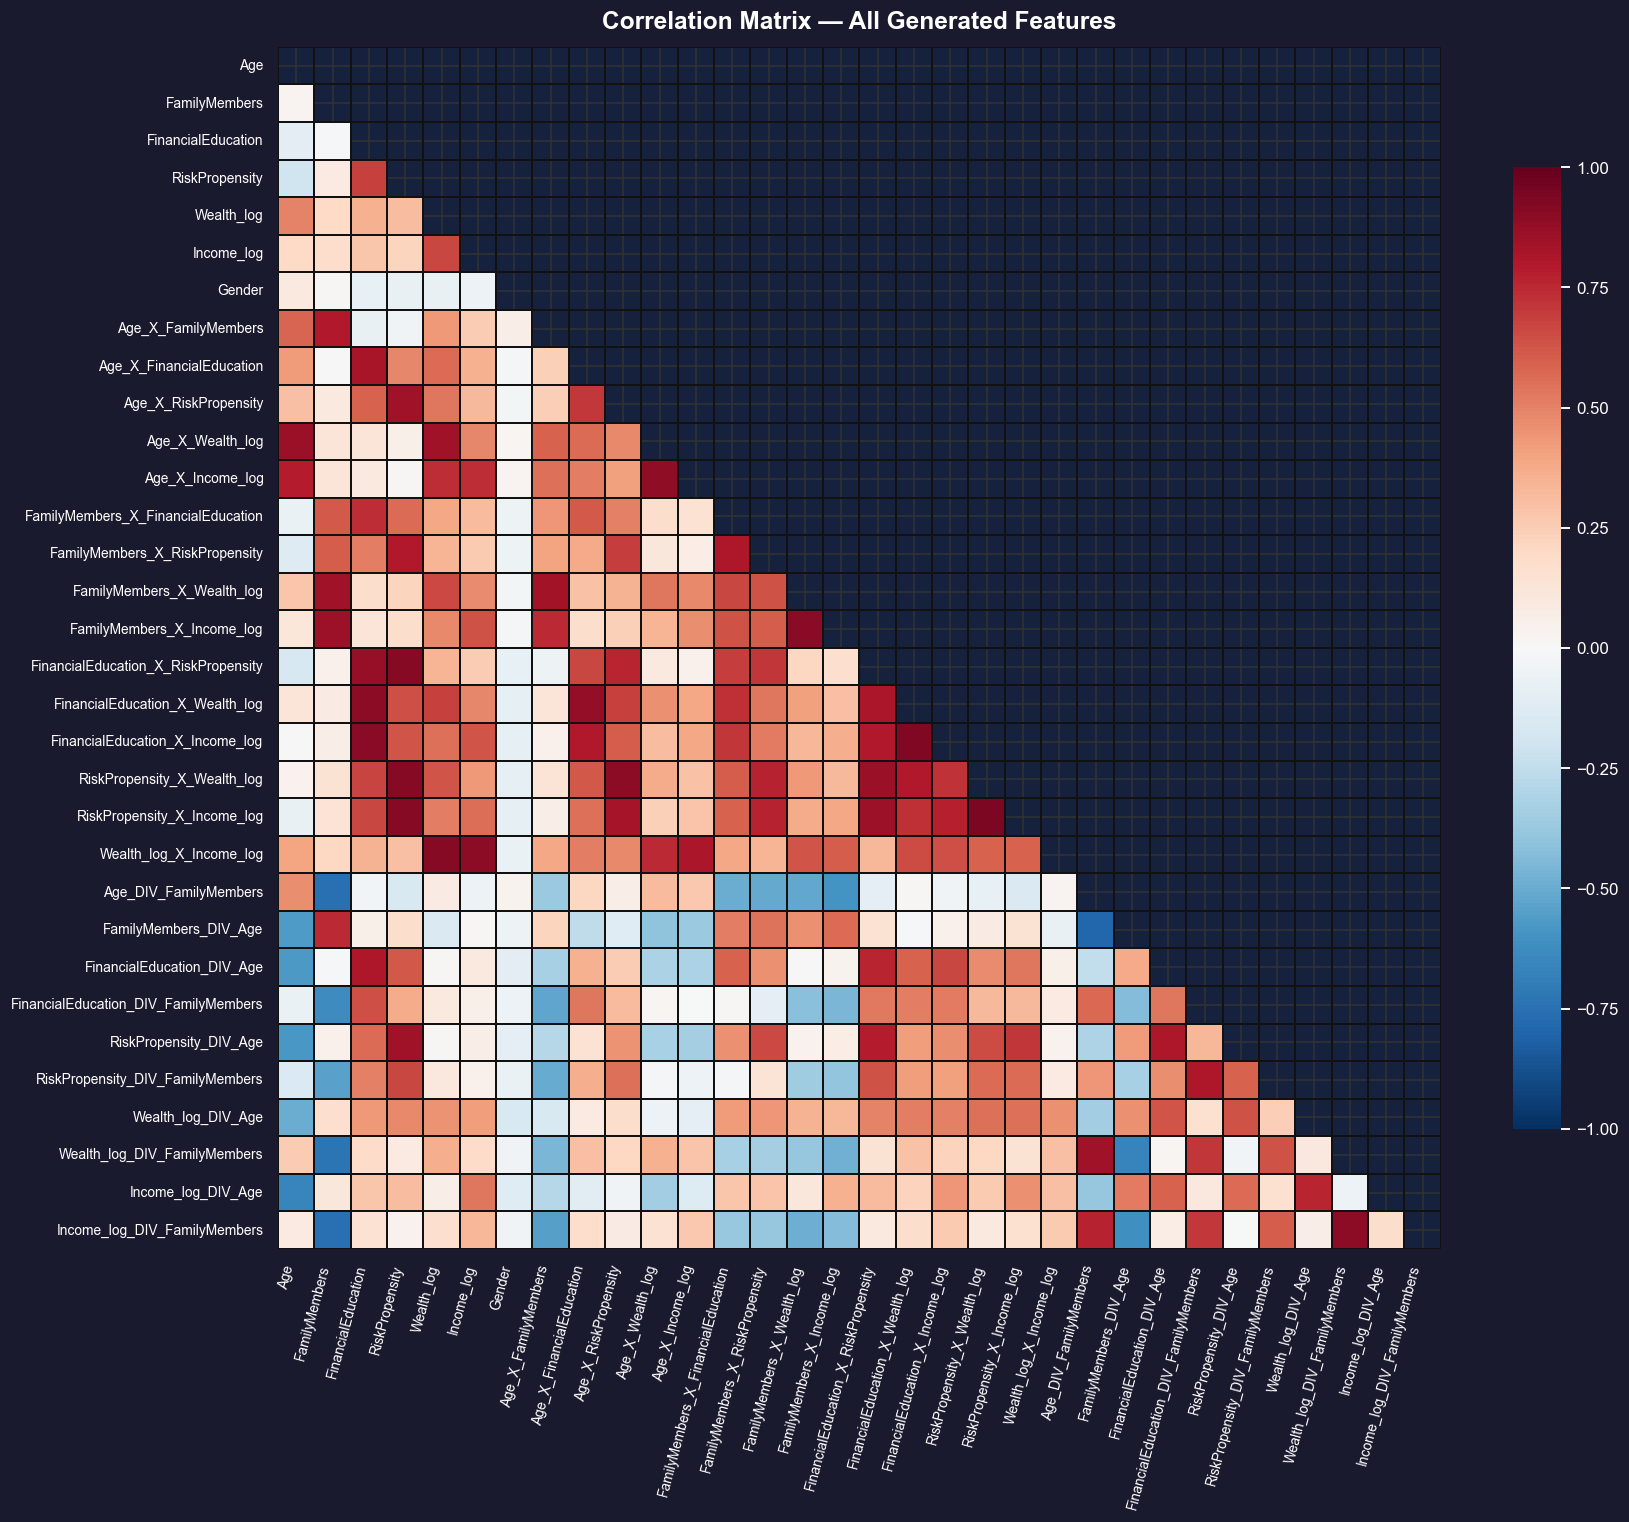


Coppie Altamente Correlate (|r| > 0.7): 66 rilevate
                          Feature A                            Feature B  Correlation
        RiskPropensity_X_Income_log          RiskPropensity_X_Wealth_log     0.938894
    FinancialEducation_X_Income_log      FinancialEducation_X_Wealth_log     0.927785
            Wealth_log_X_Income_log                           Wealth_log     0.910576
        RiskPropensity_X_Income_log                       RiskPropensity     0.910561
        RiskPropensity_X_Wealth_log                       RiskPropensity     0.909218
FinancialEducation_X_RiskPropensity                       RiskPropensity     0.907942
         FamilyMembers_X_Income_log           FamilyMembers_X_Wealth_log     0.900892
    FinancialEducation_X_Income_log                   FinancialEducation     0.900585
    FinancialEducation_X_Wealth_log                   FinancialEducation     0.898076
        RiskPropensity_X_Wealth_log                 Age_X_RiskPropensity     0.897370
 

In [43]:
def plot_correlation_matrix2(feature_df, numerical_features):
    # 1. Forziamo il tipo a float per sfuggire all'errore sulle categorie incontrato in precedenza
    corr = feature_df[numerical_features].astype(float).corr()

    # 2. Allarghiamo pesantemente la "tela" del grafico per farci stare i nomi lunghi (es. Age_X_Income_log)
    fig, ax = plt.subplots(figsize=(16, 14))
    
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 3. Spegniamo le annotazioni (numeri nei quadretti) se la mole di feature è enorme (> 15)
    show_annot = len(numerical_features) <= 15
    
    sns.heatmap(corr, mask=mask, annot=show_annot, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.2, linecolor='#111', ax=ax, cbar_kws={'shrink': 0.8})
    
    ax.set_title('Correlation Matrix — All Generated Features', fontsize=16, fontweight='bold', pad=12)
    # Assicuriamoci che i nomi in basso siano sfalzati/ruotati per potersi far leggere
    plt.xticks(rotation=75, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    
    plt.tight_layout()
    plt.show()

    # --- Estrazione delle Correlazioni Alte ---
    high_corr = (
        corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack().reset_index()
    )
    high_corr.columns = ['Feature A', 'Feature B', 'Correlation']
    # Salva le correlazioni > 0.70 o < -0.70
    high_corr = high_corr[high_corr['Correlation'].abs() > 0.7].sort_values(
        'Correlation', ascending=False)
        
    print(f"\nCoppie Altamente Correlate (|r| > 0.7): {len(high_corr)} rilevate")
    print("="*60)
    print(high_corr.to_string(index=False))



plot_correlation_matrix2(extended_feature_df, list(extended_feature_df.columns))

In [ ]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

# Step 1: Feature engineering and transformation function
def prepare_features(df):
    X = df.copy()

    # Select features for modeling
    features_base = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log']

    features_engineered_acc = ['Age', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log']
    
    features_engineered_inc = ['Age', 'FinancialEducation', 'Wealth_log',
                    'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore']
    
    # Normalize all features
    scaler = MinMaxScaler()
    X_base = pd.DataFrame(scaler.fit_transform(X[features_base]), columns=features_base)
    # Scaliamo le due nuove versioni di features
    X_engineered_acc = pd.DataFrame(scaler.fit_transform(X[features_engineered_acc]), columns=features_engineered_acc)
    X_engineered_inc = pd.DataFrame(scaler.fit_transform(X[features_engineered_inc]), columns=features_engineered_inc)

    return X_base, X_engineered_acc, X_engineered_inc

# Step 2: Data split function
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        }
    }

# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean']
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std']
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1']
        ]
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))

# Step 5: Run full analysis
# Prepare features
X_base, X_engineered_acc, X_engineered_inc = prepare_features(feature_df)

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'NaiveBayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

f1_results = []

for target_name, y in [('Income Investment', y_inc_df), ('Accumulation Investment', y_acc_df)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train_acc, X_eng_test_acc, _, _ = split_data(X_engineered_acc, y)
    X_eng_train_inc, X_eng_test_inc, _, _ = split_data(X_engineered_inc, y)

    for model_name, model in models.items():
        # RUN BASE
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Base", "F1": results_base['test_metrics']['f1']})

        # RUN ENGINEERED ACCUMULATION 
        results_eng_acc = train_evaluate_model(X_eng_train_acc, y_train, X_eng_test_acc, y_test, model)
        display_results_table(results_eng_acc, model_name, "Engineered Accumulation")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Eng. Accumulation", "F1": results_eng_acc['test_metrics']['f1']})

        # -- RUN ENGINEERED INCOME --
        results_eng_inc = train_evaluate_model(X_eng_train_inc, y_train, X_eng_test_inc, y_test, model)
        display_results_table(results_eng_inc, model_name, "Engineered Income")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Eng. Income", "F1": results_eng_inc['test_metrics']['f1']})

#Graph
df_plot = pd.DataFrame(f1_results)

# Creiamo una figura con 2 subplot (uno per Income, uno per Accumulation)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")
palette_features = {"Base": "#3498db", "Eng. Accumulation": "#2ecc71", "Eng. Income": "#e74c3c"} 

for i, target in enumerate(['Income Investment', 'Accumulation Investment']):
    # Filtriamo il dataframe per il target specifico
    df_subset = df_plot[df_plot["Target"] == target]
    
    # Plottiamo l'istogramma con raggruppamento
    sns.barplot(
        data=df_subset, x="Model", y="F1", hue="Feature Set", 
        ax=axes[i], palette=palette_features
    )
    
    axes[i].set_title(f"{target}\nConfronto Features F1-Score", fontsize=14, fontweight="bold")
    axes[i].set_ylim([0, 1.05])
    axes[i].set_ylabel("F1-Score Test Set")
    axes[i].set_xlabel("")
    axes[i].legend(title="Dataset", bbox_to_anchor=(1, 1), loc='upper left', fontsize=10)
    
    # Aggiungiamo i numeretti sopra ogni singola barra per un confronto esatto
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0: # Evitiamo di scrivere 0.000 se non ci sono predizioni (es. NaiveBayes che fa 0)
            axes[i].annotate(f'{height:.3f}', 
                             (p.get_x() + p.get_width() / 2., height),
                             ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 4), 
                             textcoords='offset points')

plt.tight_layout()
plt.show()



NameError: name 'X' is not defined



TARGET VARIABLE: INCOME INVESTMENT

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.781  |  0.02  |  0.787   |
| 1 | Precision |  0.776  | 0.028  |  0.777   |
| 2 |  Recall   |  0.604  | 0.024  |  0.625   |
| 3 |    F1     |  0.679  | 0.021  |  0.693   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/3083484640.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


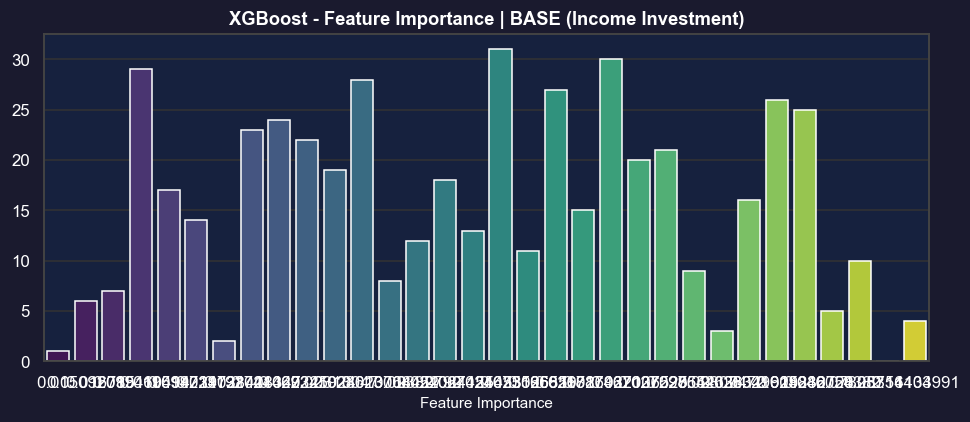



TARGET VARIABLE: ACCUMULATION INVESTMENT

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.769  | 0.012  |  0.788   |
| 1 | Precision |  0.796  | 0.013  |  0.829   |
| 2 |  Recall   |  0.737  | 0.025  |  0.739   |
| 3 |    F1     |  0.765  | 0.018  |  0.781   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/3083484640.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


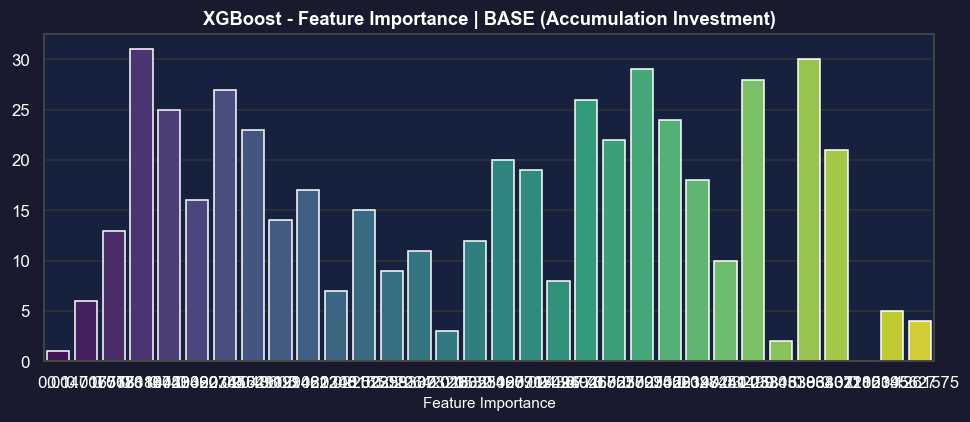

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
import xgboost as xgb

# Step 2: Data split function
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        },
        'model': model
    }

# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean']
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std']
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1']
        ]
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))


def plot_feature_importance(model, feature_names, title, top_n=20):
    importances = pd.DataFrame({
        'feature': [str(f) for f in feature_names],
        'importance': model.feature_importances_
    })
    importances = importances.sort_values('importance', ascending=False).head(top_n)

    fig_height = max(4.0, len(importances) * 0.3)
    plt.figure(figsize=(9, fig_height))
    sns.barplot(data=importances, x='importance', y='feature', palette="viridis", orient='h')
    plt.title(f"{title} (Top {top_n})", fontweight="bold")
    plt.xlabel('Feature Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()



    
scaler = MinMaxScaler()
X_extended = pd.DataFrame(scaler.fit_transform(extended_feature_df))

for target_name, y in [('Income Investment', y_inc_df), ('Accumulation Investment', y_acc_df)]:
    print(f"\n\n{'=' * 80}")
    print(f"TARGET VARIABLE: {target_name}".upper())
    print(f"{'=' * 80}")

    # Splittiamo tutti i set
    X_base_train, X_base_test, y_train, y_test = split_data(X_extended, y)

    for model_name, model in models.items():
        # ==================== RUN BASE ====================
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Base", "F1": results_base['test_metrics']['f1']})
        
        # Disegniamo la Feature Importance se il modello lo permette (es. Random Forest o XGBoost)
        if hasattr(results_base['model'], 'feature_importances_'):
            plot_feature_importance(results_base['model'], X_extended.columns, f"{model_name} - Feature Importance | BASE ({target_name})")



TARGET VARIABLE: INCOME INVESTMENT

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.782  | 0.013  |  0.783   |
| 1 | Precision |  0.779  | 0.041  |  0.777   |
| 2 |  Recall   |  0.605  | 0.022  |  0.609   |
| 3 |    F1     |  0.68   | 0.011  |  0.683   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


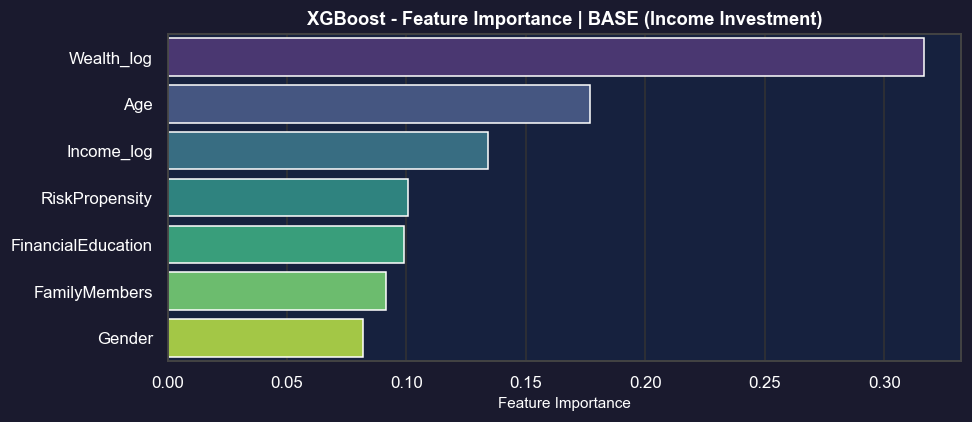


XGBoost - Engineered Accumulation
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.786  |  0.01  |  0.806   |
| 1 | Precision |  0.775  | 0.013  |  0.825   |
| 2 |  Recall   |  0.622  |  0.01  |  0.628   |
| 3 |    F1     |  0.69   | 0.008  |  0.713   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


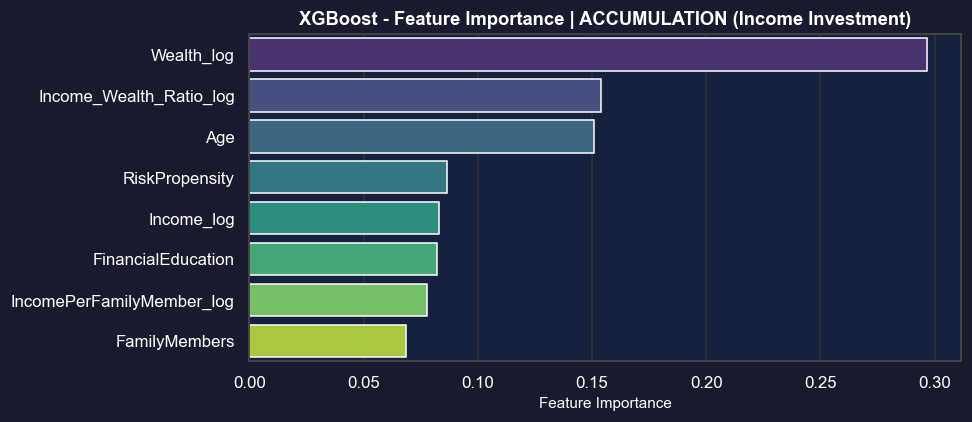


XGBoost - Engineered Income
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.791  | 0.017  |  0.802   |
| 1 | Precision |  0.794  | 0.015  |   0.81   |
| 2 |  Recall   |  0.617  | 0.024  |  0.633   |
| 3 |    F1     |  0.694  |  0.02  |  0.711   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


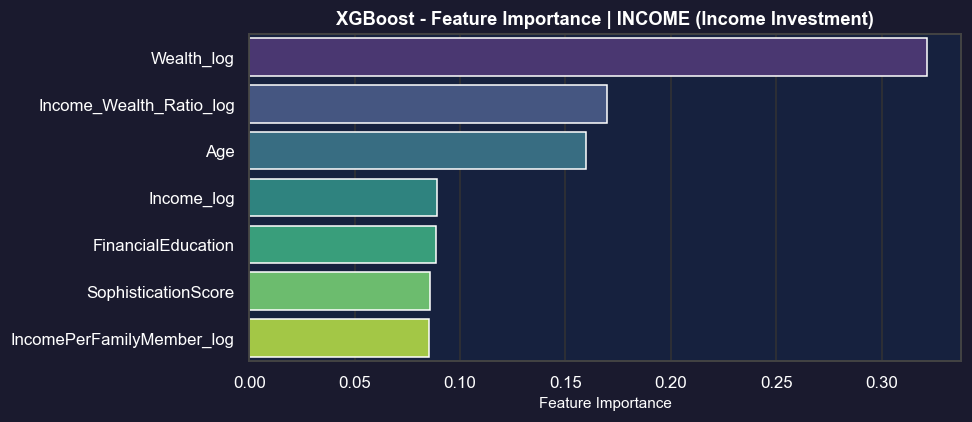



TARGET VARIABLE: ACCUMULATION INVESTMENT

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.775  | 0.013  |  0.793   |
| 1 | Precision |  0.803  | 0.014  |  0.834   |
| 2 |  Recall   |  0.744  | 0.024  |  0.745   |
| 3 |    F1     |  0.772  | 0.019  |  0.787   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


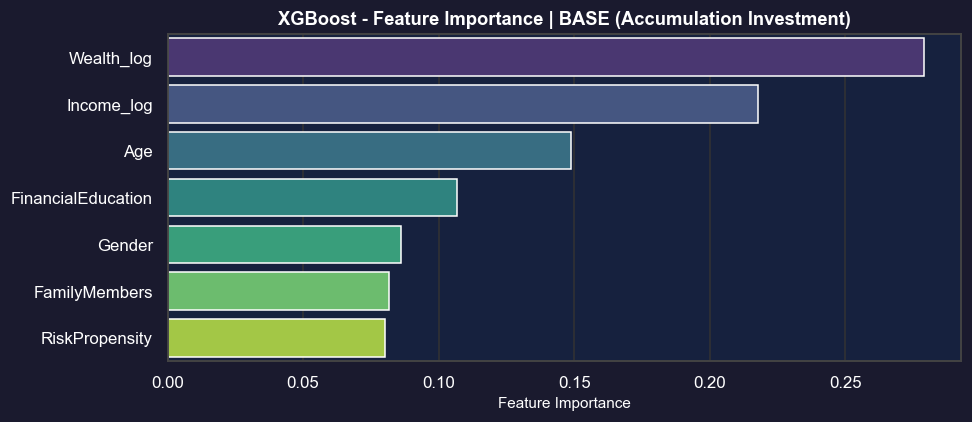


XGBoost - Engineered Accumulation
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.805  | 0.011  |  0.811   |
| 1 | Precision |  0.851  |  0.01  |  0.877   |
| 2 |  Recall   |  0.75   | 0.022  |  0.735   |
| 3 |    F1     |  0.797  | 0.016  |   0.8    |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


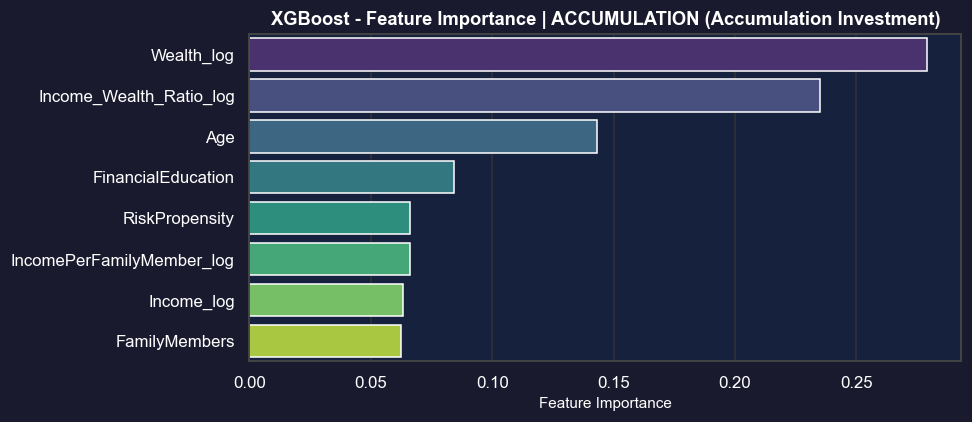


XGBoost - Engineered Income
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.801  | 0.009  |  0.813   |
| 1 | Precision |  0.85   | 0.003  |  0.872   |
| 2 |  Recall   |  0.743  | 0.028  |  0.745   |
| 3 |    F1     |  0.793  | 0.015  |  0.803   |
+---+-----------+---------+--------+----------+


/var/folders/s_/l47pb7t11nddlv_zq53jynww0000gn/T/ipykernel_32252/390632433.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='importance', y='feature', palette="viridis")


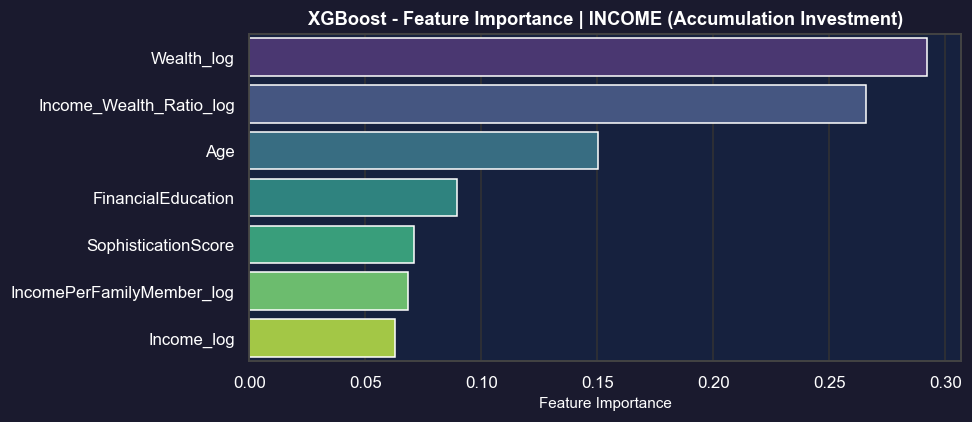

Ellipsis

In [50]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb

# Step 1: Feature engineering and transformation function
def prepare_features(df):
    X = df.copy()

    # Select features for modeling
    features_base = ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log']

    features_engineered_acc = ['Age', 'FamilyMembers', 'FinancialEducation',
                    'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log']
    
    features_engineered_inc = ['Age', 'FinancialEducation', 'Wealth_log',
                    'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore']
    
    # Normalize all features
    scaler = MinMaxScaler()
    X_base = pd.DataFrame(scaler.fit_transform(X[features_base]), columns=features_base)
    # Scaliamo le due nuove versioni di features
    X_engineered_acc = pd.DataFrame(scaler.fit_transform(X[features_engineered_acc]), columns=features_engineered_acc)
    X_engineered_inc = pd.DataFrame(scaler.fit_transform(X[features_engineered_inc]), columns=features_engineered_inc)

    return X_base, X_engineered_acc, X_engineered_inc

# Step 2: Data split function
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

# Step 3: Model training and evaluation function
def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics['accuracy'].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics['precision'].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics['recall'].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics['f1'].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        'cv_metrics': {
            metric: {
                'mean': np.mean(scores),
                'std': np.std(scores)
            } for metric, scores in cv_metrics.items()
        },
        'test_metrics': {
            'accuracy': accuracy_score(y_test, y_test_pred),
            'precision': precision_score(y_test, y_test_pred),
            'recall': recall_score(y_test, y_test_pred),
            'f1': f1_score(y_test, y_test_pred)
        },
        'model': model
    }

# Step 4: Display results function
def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
        'CV Mean': [
            results_dict['cv_metrics']['accuracy']['mean'],
            results_dict['cv_metrics']['precision']['mean'],
            results_dict['cv_metrics']['recall']['mean'],
            results_dict['cv_metrics']['f1']['mean']
        ],
        'CV Std': [
            results_dict['cv_metrics']['accuracy']['std'],
            results_dict['cv_metrics']['precision']['std'],
            results_dict['cv_metrics']['recall']['std'],
            results_dict['cv_metrics']['f1']['std']
        ],
        'Test Set': [
            results_dict['test_metrics']['accuracy'],
            results_dict['test_metrics']['precision'],
            results_dict['test_metrics']['recall'],
            results_dict['test_metrics']['f1']
        ]
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers='keys', tablefmt='pretty'))

# ======================================================================
# DEFINIZIONE FUNZIONE: FEATURE IMPORTANCE
# ======================================================================
def plot_feature_importance(model, feature_names, title, top_n=20):
    importances = pd.DataFrame({
        'feature': [str(f) for f in feature_names],
        'importance': model.feature_importances_
    })
    importances = importances.sort_values('importance', ascending=False).head(top_n)

    fig_height = max(4.0, len(importances) * 0.3)
    plt.figure(figsize=(9, fig_height))
    sns.barplot(data=importances, x='importance', y='feature', palette="viridis", orient='h')
    plt.title(f"{title} (Top {top_n})", fontweight="bold")
    plt.xlabel('Feature Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# ======================================================================
# STEP 5: RUN FULL ANALYSIS (Tabelle + Istogrammi + Feature Imp.)
# ======================================================================
# ... Recupero Features e Costruzione modli omessi (lasciali come li hai già)

f1_results = []

for target_name, y in [('Income Investment', y_inc_df), ('Accumulation Investment', y_acc_df)]:
    print(f"\n\n{'=' * 80}")
    print(f"TARGET VARIABLE: {target_name}".upper())
    print(f"{'=' * 80}")

    # Splittiamo tutti i set
    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train_acc, X_eng_test_acc, _, _ = split_data(X_engineered_acc, y)
    X_eng_train_inc, X_eng_test_inc, _, _ = split_data(X_engineered_inc, y)

    for model_name, model in models.items():
        # ==================== RUN BASE ====================
        results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
        display_results_table(results_base, model_name, "Base Features")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Base", "F1": results_base['test_metrics']['f1']})
        
        # Disegniamo la Feature Importance se il modello lo permette (es. Random Forest o XGBoost)
        if hasattr(results_base['model'], 'feature_importances_'):
            plot_feature_importance(results_base['model'], X_base.columns, f"{model_name} - Feature Importance | BASE ({target_name})")

        # ==================== RUN ENGINEERED ACCUMULATION ====================
        results_eng_acc = train_evaluate_model(X_eng_train_acc, y_train, X_eng_test_acc, y_test, model)
        display_results_table(results_eng_acc, model_name, "Engineered Accumulation")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Eng. Accumulation", "F1": results_eng_acc['test_metrics']['f1']})
        
        if hasattr(results_eng_acc['model'], 'feature_importances_'):
            plot_feature_importance(results_eng_acc['model'], X_engineered_acc.columns, f"{model_name} - Feature Importance | ACCUMULATION ({target_name})")

        # ==================== RUN ENGINEERED INCOME ====================
        results_eng_inc = train_evaluate_model(X_eng_train_inc, y_train, X_eng_test_inc, y_test, model)
        display_results_table(results_eng_inc, model_name, "Engineered Income")
        f1_results.append({"Target": target_name, "Model": model_name, "Feature Set": "Eng. Income", "F1": results_eng_inc['test_metrics']['f1']})
        
        if hasattr(results_eng_inc['model'], 'feature_importances_'):
            plot_feature_importance(results_eng_inc['model'], X_engineered_inc.columns, f"{model_name} - Feature Importance | INCOME ({target_name})")


# (Aggiungi qui il codice del doppio Plot Seaborn Comparativo scritto nei messaggi precedenti)
...


In [19]:
import xgboost as xgb

# Updated XGBoost configuration
models = {
    'XGBoost': xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )
}

# Run the analysis
for target_name, y in [('Income Investment', y_inc_df), ('Accumulation Investment', y_acc_df)]:
    print(f"\nTarget Variable: {target_name}")
    print("=" * 80)

    X_base_train, X_base_test, y_train, y_test = split_data(X_base, y)
    X_eng_train_acc, X_eng_test_acc, _, _ = split_data(X_engineered_acc, y)
    X_eng_train_inc, X_eng_test_inc, _, _ = split_data(X_engineered_inc, y)

    model = models['XGBoost']

    results_base = train_evaluate_model(X_base_train, y_train, X_base_test, y_test, model)
    display_results_table(results_base, 'XGBoost', "Base Features")

    results_eng_acc = train_evaluate_model(X_eng_train_acc, y_train, X_eng_test_acc, y_test, model)
    display_results_table(results_eng_acc, model_name, "Engineered Features Accumulation")

    results_eng_inc = train_evaluate_model(X_eng_train_inc, y_train, X_eng_test_inc, y_test, model)
    display_results_table(results_eng_inc, model_name, "Engineered Features Income")


    #svm_inc_model, svm_inc_results, svm_inc_prob, svm_inc_pred = run_experiment(
    #"xgb", "Income",
    #X_base_train, y_train, X_base_test, y_test,
    #tune=True,
    #)



Target Variable: Income Investment

XGBoost - Base Features
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.782  | 0.013  |  0.783   |
| 1 | Precision |  0.779  | 0.041  |  0.777   |
| 2 |  Recall   |  0.605  | 0.022  |  0.609   |
| 3 |    F1     |  0.68   | 0.011  |  0.683   |
+---+-----------+---------+--------+----------+

XGBoost - Engineered Features Accumulation
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test Set |
+---+-----------+---------+--------+----------+
| 0 | Accuracy  |  0.786  |  0.01  |  0.806   |
| 1 | Precision |  0.775  | 0.013  |  0.825   |
| 2 |  Recall   |  0.622  |  0.01  |  0.628   |
| 3 |    F1     |  0.69   | 0.008  |  0.713   |
+---+-----------+---------+--------+----------+

XGBoost - Engineered Features Income
+---+-----------+---------+--------+----------+
|   |  Metric   | CV Mean | CV Std | Test

In [20]:
# feature_df = feature_df.drop(columns='SophisticationScore')
NUMERICAL_FEATURES = [f for f in NUMERICAL_FEATURES if f != 'SophisticationScore']
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

print(f'Features after drop: {feature_df.shape[1]}')
print(feature_df.columns.tolist())

Features after drop: 10
['Age', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log', 'IncomePerFamilyMember_log', 'Income_Wealth_Ratio_log', 'SophisticationScore', 'Gender']


---
## 8. FAMD (Factor Analysis of Mixed Data)

Handles mixed numerical + categorical features in a single reduction step — no manual scaling or encoding needed.

In [21]:
N_COMPONENTS = 8
famd = prince.FAMD(n_components=N_COMPONENTS, n_iter=10, copy=True,
                   check_input=True, engine='sklearn', random_state=42)

X_famd = famd.fit_transform(feature_df.copy())
X_famd.columns = [f'Dim_{i+1}' for i in range(N_COMPONENTS)]

explained_var  = famd.percentage_of_variance_
cumulative_var = np.cumsum(explained_var)

print('Variance explained per component:')
for k, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f'  Dim {k}: {ev:.2f}%   cumulative: {cv:.2f}%')
print(f'\nTotal ({N_COMPONENTS} dims): {cumulative_var[-1]:.2f}%')

Variance explained per component:
  Dim 1: 2.74%   cumulative: 2.74%
  Dim 2: 1.88%   cumulative: 4.62%
  Dim 3: 1.54%   cumulative: 6.15%
  Dim 4: 1.52%   cumulative: 7.68%
  Dim 5: 1.44%   cumulative: 9.12%
  Dim 6: 1.34%   cumulative: 10.45%
  Dim 7: 1.29%   cumulative: 11.74%
  Dim 8: 1.20%   cumulative: 12.94%

Total (8 dims): 12.94%


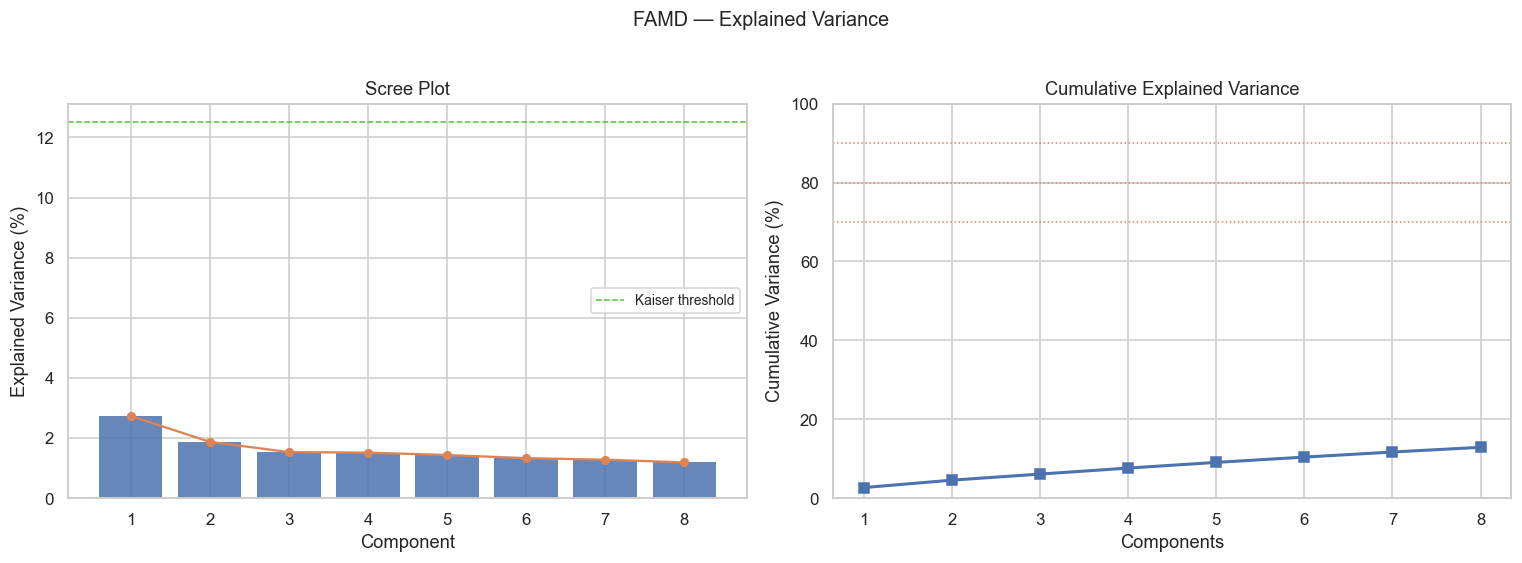

In [22]:
plots.plot_scree(explained_var, cumulative_var)

### Key finding:
The low explained variance confirms feature independence — no dominant latent structure — consistent with the weak clustering signal found downstream

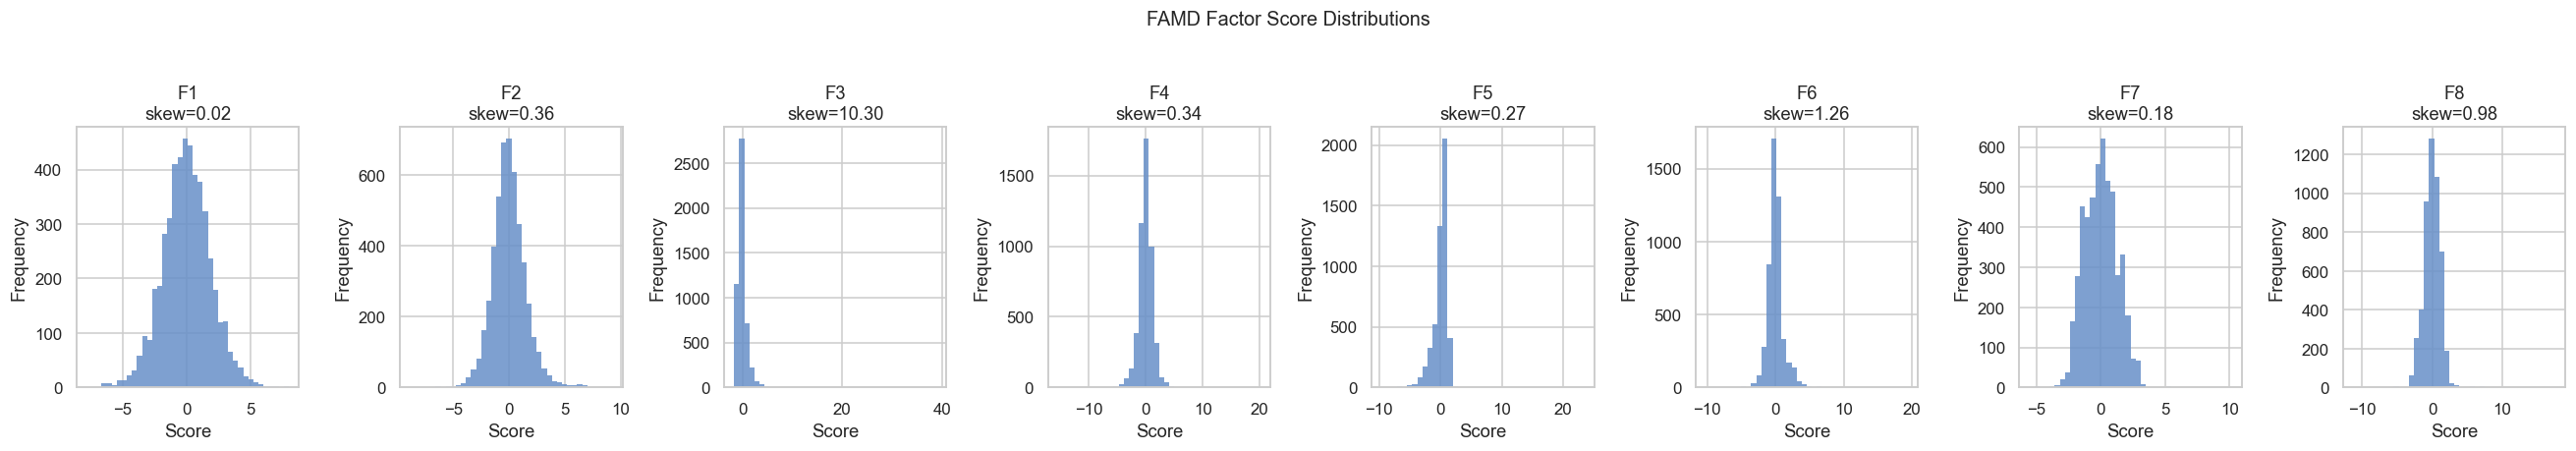

⚠️  High skew: ['F3']


In [23]:
factor_cols = [f'F{i+1}' for i in range(N_COMPONENTS)]
factors_df  = pd.DataFrame(X_famd.values, columns=factor_cols, index=feature_df.index)

plots.plot_factor_distributions(factors_df, factor_cols)

skews   = factors_df.skew().round(3)
flagged = skews[skews.abs() > 2.0]
if len(flagged):
    print(f'⚠️  High skew: {flagged.index.tolist()}')
else:
    print('✓ Factor distributions are reasonably symmetric.')

---
## 9. GMM Clustering

Soft clustering — each customer gets a probability per cluster rather than a hard label. Sweep k = 2…10; BIC is the primary selection criterion.

In [24]:
K_RANGE    = range(2, 11)
bic_scores = []
aic_scores = []
sil_scores = []
F_array    = factors_df.values

for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          n_init=5, random_state=SEED)
    gmm.fit(F_array)
    labels = gmm.predict(F_array)
    bic_scores.append(gmm.bic(F_array))
    aic_scores.append(gmm.aic(F_array))
    sil_scores.append(silhouette_score(F_array, labels))
    print(f'  k={k:2d}  BIC={bic_scores[-1]:>12,.1f}  '
          f'AIC={aic_scores[-1]:>12,.1f}  Sil={sil_scores[-1]:.4f}')

print('\nSweep complete.')

  k= 2  BIC=   116,007.4  AIC=   115,427.4  Sil=0.2717
  k= 3  BIC=   108,879.4  AIC=   108,006.1  Sil=0.1578
  k= 4  BIC=   107,164.4  AIC=   105,997.9  Sil=0.0819
  k= 5  BIC=   105,456.0  AIC=   103,996.1  Sil=-0.0098
  k= 6  BIC=   103,545.6  AIC=   101,792.4  Sil=0.0139
  k= 7  BIC=   103,008.5  AIC=   100,962.1  Sil=0.0106
  k= 8  BIC=    99,230.6  AIC=    96,890.9  Sil=0.0071
  k= 9  BIC=    97,636.2  AIC=    95,003.3  Sil=0.0004
  k=10  BIC=    97,111.4  AIC=    94,185.1  Sil=0.0096

Sweep complete.


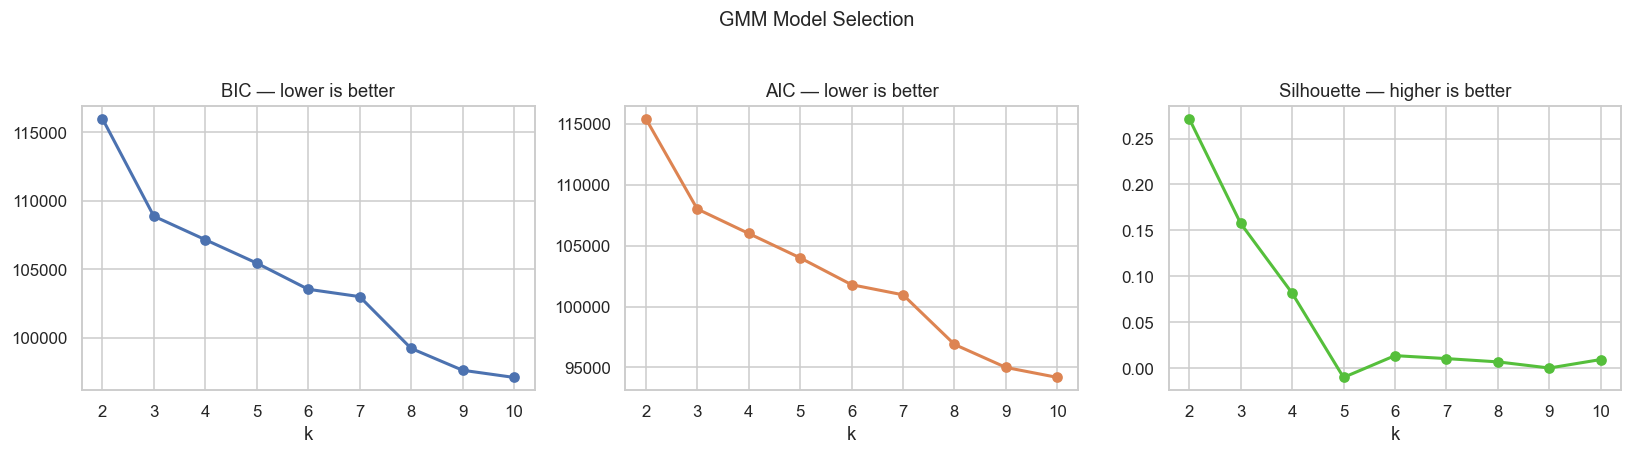

Best k by BIC       : 10
Best k by Silhouette: 2


In [25]:
plots.plot_gmm_selection(list(K_RANGE), bic_scores, aic_scores, sil_scores)

best_k = list(K_RANGE)[int(np.argmin(bic_scores))]
print(f'Best k by BIC       : {best_k}')
print(f'Best k by Silhouette: {list(K_RANGE)[int(np.argmax(sil_scores))]}')

<code>Gender</code> feature is dropped since they showed little relevance in data exploration.

In [26]:
# feature_df = feature_df.drop(columns='Gender')


---
## 10. Summary, Findings & Next Steps

### What We Did
- Cleaned data: dropped ID, shuffled, separated targets
- Applied `log1p` to skewed financial variables
- Engineered 3 features; dropped `SophisticationScore` after supervised EDA confirmed redundancy
- Ran unsupervised EDA (distributions, correlation matrix)
- Ran supervised EDA (pairplots, boxplots, point-biserial correlations)
- Reduced feature space with FAMD (8 components)
- Assessed cluster structure with GMM (k = 2…10)

---

### Key Findings

**FAMD:** ~13% total variance across 8 components — no dominant shared latent structure.

**GMM:** No BIC elbow; silhouette scores near zero — no meaningful cluster structure.

**Supervised EDA:** Signal exists but is weak and distributed. `Wealth` and `Age` drive `IncomeInvestment`; `Income` and family-adjusted income drive `AccumulationInvestment`. `Income_Wealth_Ratio_log` is the most discriminative engineered feature.

**What to expect:** ensemble methods (Random Forest, Gradient Boosting) are expected to outperform linear models, since signals are weak and distributed


**Conclusion:** The customer population is a continuous spectrum, not discrete segments. Data-driven clustering is not supported.


---

### What Didn't Work
- GMM / K-Means clustering — no stable segments
- `SophisticationScore` — redundant, dropped
- Therefore, a Mixture of Experts gated by GMM clusters method is not justified by the data


### Next Steps
1. Train classifiers for `IncomeInvestment` and `AccumulationInvestment`
2. Evaluate — ensemble methods (Random Forest, Gradient Boosting) expected to outperform linear models
3. Build recommendation engine on top of predictions

In [1]:
output_path = 'processed_features.xlsx'

with pd.ExcelWriter(output_path) as writer:
    feature_df.to_excel(writer, sheet_name='features', index=True)
   # factors_df.to_excel(writer, sheet_name='famd_factors', index=True)
    df[['IncomeInvestment', 'AccumulationInvestment']].to_excel(
        writer, sheet_name='targets', index=True)

print(f'Saved: {output_path}')
print(f'  features     : {feature_df.shape}')
#print(f'  famd_factors : {factors_df.shape}')
print(f'  targets      : {df[["IncomeInvestment","AccumulationInvestment"]].shape}')

NameError: name 'pd' is not defined